In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import exp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import scale
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import csv

## Setup
Getting info and exploring the data

In [8]:
filename = 'mini-itc-data.csv'

df = pd.read_csv(filename)
print('done reading')

df.info()
df.head()

done reading
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   system_name                    100 non-null    object 
 1   region                         100 non-null    object 
 2   attack_type                    100 non-null    object 
 3   data_sensitivity_level         100 non-null    int64  
 4   records_exposed                100 non-null    int64  
 5   estimated_cost_per_record_usd  100 non-null    float64
 6   estimated_total_cost_usd       100 non-null    float64
 7   detection_delay_days           100 non-null    int64  
 8   response_time_days             100 non-null    int64  
 9   notification_required          100 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 7.9+ KB


,system_name,region,attack_type,data_sensitivity_level,records_exposed,estimated_cost_per_record_usd,estimated_total_cost_usd,detection_delay_days,response_time_days,notification_required
0,CRM,latam-south2,External Hacker,4,56681,17.91,1014973.29,18,7,Yes
1,CRM,ca-central1,Misconfiguration,4,97901,18.07,1769502.68,10,9,Yes
2,Support,africa-south1,Misconfiguration,3,16274,13.34,217074.77,3,3,Yes
3,Billing,asia-south1,Insider,5,41640,21.44,892759.36,9,4,Yes
4,HR,eu-north1,Misconfiguration,5,45484,21.09,959464.03,7,7,Yes


## Cleaning
Sort by region


In [27]:
# Group by region and system, summing total cost
region_system_costs = (
    df.groupby(['region', 'system_name'])['estimated_total_cost_usd']
      .sum()
      .reset_index()
)

# Pivot so each system_name becomes its own column
region_summary = (
    region_system_costs
    .pivot(index='region', columns='system_name', values='estimated_total_cost_usd')
    .fillna(0)  # optional: replace NaN with 0
)

# Add total per region
region_summary['total_region_damage_usd'] = region_summary.sum(axis=1)
region_summary = region_summary.reset_index()

region_summary = region_summary.sort_values(by='total_region_damage_usd', ascending=False)

print(region_summary)

system_name         region  Analytics     Billing         CRM          HR  \
15            latam-north1       0.00  2556820.26  1112578.57  1239538.35   
1            ap-northeast1  110760.18  2471140.33    70718.62  1542276.81   
3                ap-south1  193859.47  2460599.64   495641.02   580770.87   
21                us-east1  175077.91  1597822.84  1287403.49   848172.57   
16            latam-south1  128575.95  1495863.33   878606.78  1242681.02   
12               eu-north1  176791.46  1297872.67  1072929.30   959464.03   
2            ap-northeast2   76645.42  1359560.59   666793.10  1229052.56   
9              ca-central1   90380.92   504431.92  1769502.68   813476.32   
18             me-central1  232317.63  1911226.49   708707.71   533177.07   
20             us-central2   87564.51  1523155.45        0.00  1342820.04   
14                eu-west2       0.00   908904.60   521096.97  1308775.91   
25                us-west2   57098.71  1944103.28        0.00   687025.54   

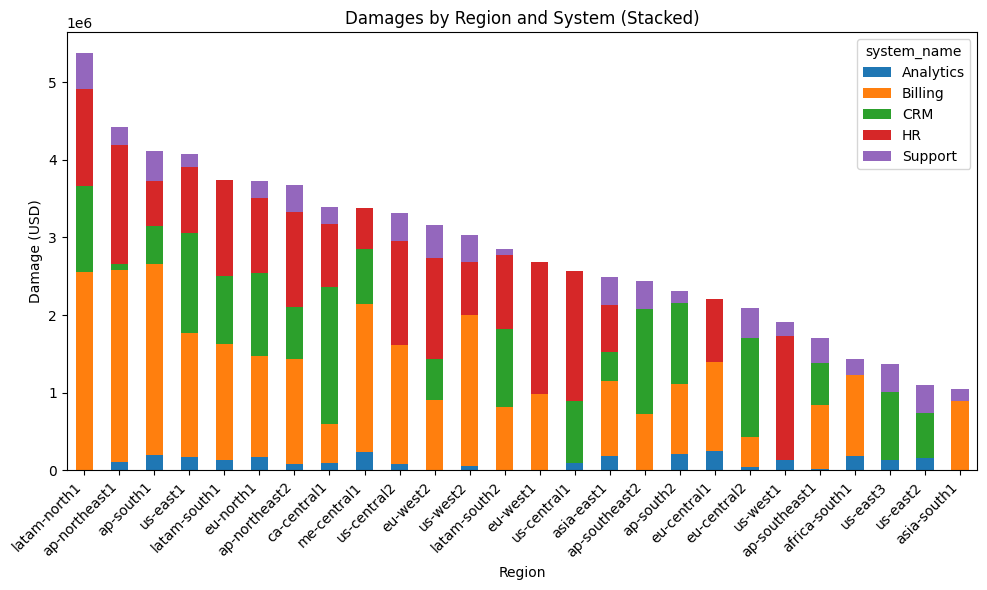

In [28]:
#plot graph
region_summary = region_summary.set_index('region')

ax = region_summary.drop(columns='total_region_damage_usd').plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)
ax.set_xlabel('Region')
ax.set_ylabel('Damage (USD)')
ax.set_title('Damages by Region and System (Stacked)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()